In [1]:
ROOT = '/kaggle/input/datasets/harshdatt'

We want to use ResNeXt image embeddings to make an exploratory plot, so let's add some code to get our embeddings.

In [2]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
import numpy as np


DEVICE = torch.device('cpu')
OUTPUT_SIZE = 2048

model = models.resnext50_32x4d(weights=models.ResNeXt50_32X4D_Weights.IMAGENET1K_V2)

extraction_layer = model._modules.get('avgpool')
model.to(DEVICE)
model.eval()

scaler = transforms.Resize((224, 224))
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
to_tensor = transforms.ToTensor()

def get_vec(arg, model, extraction_layer):
    image = normalize(to_tensor(scaler(arg))).unsqueeze(0).to(DEVICE)
    result = torch.zeros(1, OUTPUT_SIZE, 1, 1)
    def copy_data(m, i, o):
        result.copy_(o.data)
    hooked = extraction_layer.register_forward_hook(copy_data)
    with torch.no_grad():
        model(image)
    hooked.remove()
    return result

Downloading: "https://download.pytorch.org/models/resnext50_32x4d-1a0047aa.pth" to /root/.cache/torch/hub/checkpoints/resnext50_32x4d-1a0047aa.pth


100%|██████████| 95.8M/95.8M [00:00<00:00, 184MB/s]


Let's load all of our data. We have less than 150 instances, so this should just take a minute or so.

In [3]:
import arrow
import base64
import pandas as pd
import tqdm

from glob import iglob
from io import BytesIO
from os.path import basename
from os.path import isdir
from PIL import Image

THUMBNAIL_SIZE = (64, 64)

def embed(model, filename: str):
    try:
        with Image.open(fp=filename, mode='r') as image:
            return get_vec(arg=image.convert('RGB'), model=model, extraction_layer=extraction_layer).numpy().reshape(OUTPUT_SIZE,)
    except: 
        print(filename)
        return None


# https://stackoverflow.com/a/952952
def flatten(arg):
    return [x for xs in arg for x in xs]

def png(filename: str) -> str:
    with Image.open(fp=filename, mode='r') as image:
        buffer = BytesIO()
        image.resize(size=THUMBNAIL_SIZE).convert('RGB').save(buffer, format='png')
        return 'data:image/png;base64,' + base64.b64encode(buffer.getvalue()).decode()

def get_picture_from_glob(arg: str, tag: str,) -> list:
    result = [pd.Series(data=[tag, basename(input_file), embed(model=model, filename=input_file), png(filename=input_file)],
                        index=['tag', 'name', 'value', 'png'])
        for index, input_file in enumerate(tqdm.tqdm(desc='images', iterable=list(iglob(pathname=arg)))) if input_file.endswith('.jpg') or input_file.endswith('.png')]
    return result

time_start = arrow.now()
train_dict = {basename(folder) : folder + '/*.*' for folder in iglob(ROOT + '/*') if isdir(folder)}
train_df = pd.DataFrame(data=flatten(arg=[get_picture_from_glob(arg=value, tag=key) for (key, value) in train_dict.items()]))
train_df['tag'] = 'architecture'
print('done in {}'.format(arrow.now() - time_start))

images: 100%|██████████| 139/139 [01:07<00:00,  2.05it/s]

done in 0:01:07.864701


Let's use TSNE to add x/y coordinates based on our image embeddings.

In [4]:
from sklearn.manifold import TSNE

train_reducer = TSNE(random_state=2026, verbose=True, n_jobs=1, perplexity=20.0, init='pca')
train_df[['x', 'y']] = train_reducer.fit_transform(X=train_df['value'].apply(func=pd.Series))

[t-SNE] Computing 61 nearest neighbors...
[t-SNE] Indexed 139 samples in 0.002s...
[t-SNE] Computed neighbors for 139 samples in 0.055s...
[t-SNE] Computed conditional probabilities for sample 139 / 139
[t-SNE] Mean sigma: 5.864983
[t-SNE] KL divergence after 250 iterations with early exaggeration: 55.446594
[t-SNE] KL divergence after 1000 iterations: 0.342344


Let's plot.

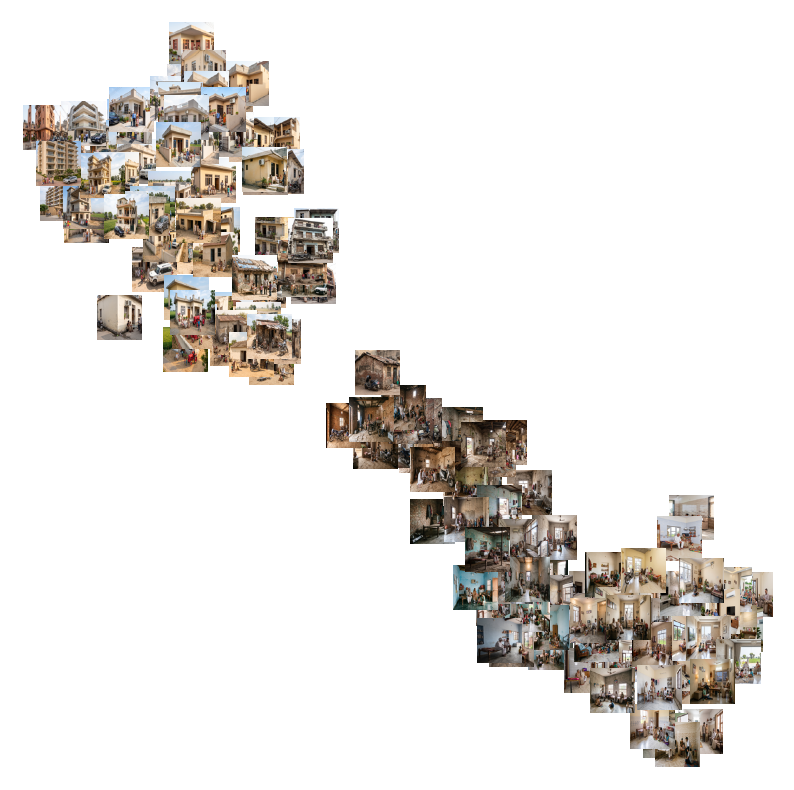

In [5]:
import base64
import io
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.offsetbox import AnnotationBbox, OffsetImage
from PIL import Image

# we recycled some PNG encoding code above, and we need to postprocess it for using with matplotlib
train_df['PNG'] = train_df['png'].str.replace('^data:image/png;base64,', '', regex=True)

fig, ax = plt.subplots(figsize=(10, 10))

for index, row in train_df.iterrows():
    img_bytes = base64.b64decode(row["PNG"])
    img = Image.open(io.BytesIO(img_bytes))
    imagebox = OffsetImage(img, zoom=0.5)
    ab = AnnotationBbox(imagebox, (row["x"], row["y"]), frameon=False, pad=0)
    ax.add_artist(ab)
ax.scatter(train_df["x"], train_df["y"], alpha=0)
ax.axis('off')
plt.show()


What do we see? Our data separates into two clusters: exterior images and interior images. The interior images cluster more or less from dark to light.